# Global Macro Dashboard — Analytical Notebook
**ACC102 Mini Assignment | Track 4 — Interactive Data Tool**

This notebook documents the full analytical workflow behind the Global Macro Dashboard,
covering data acquisition, cleaning, exploratory analysis, and visualisation.

- **Data Source:** World Bank World Development Indicators
- **URL:** https://databank.worldbank.org/source/world-development-indicators
- **Indicators:** GDP Growth (%), Inflation (%), Unemployment (%)
- **Countries:** China, USA, UK, Germany, Japan, India, Brazil
- **Period:** 2000–2025
- **Accessed:** April 2026

## 1. Setup — Import Libraries

In [10]:
# Note: Dependencies are listed in requirements.txt
# Run: pip install -r requirements.txt
# The following line installs packages if running in a fresh environment
!pip install plotly pandas statsmodels

## 2. Data Acquisition — Load World Bank CSV

In [2]:
import pandas as pd
import plotly.express as px

# Load official World Bank CSV
# Data source: World Bank World Development Indicators
# URL: https://databank.worldbank.org/source/world-development-indicators
# Indicators: NY.GDP.MKTP.KD.ZG, FP.CPI.TOTL.ZG, SL.UEM.TOTL.ZS
# Countries: China, Germany, India, Japan, Brazil, United Kingdom, United States
# Accessed: April 2026

df_raw = pd.read_csv('006b97a1-9105-4347-81fc-a2f025bfe73b_Data.csv')

df_raw = df_raw.rename(columns={
    'Country Name': 'economy',
    'Country Code': 'country_code',
    'Series Name':  'series_name',
    'Series Code':  'series_code'
})

indicator_map = {
    'NY.GDP.MKTP.KD.ZG': 'GDP Growth (%)',
    'FP.CPI.TOTL.ZG':    'Inflation (%)',
    'SL.UEM.TOTL.ZS':    'Unemployment (%)'
}
df_raw = df_raw[df_raw['series_code'].isin(indicator_map.keys())].copy()
df_raw['indicator'] = df_raw['series_code'].map(indicator_map)

year_cols = [c for c in df_raw.columns if 'YR' in c]
df_melt = df_raw.melt(
    id_vars=['economy', 'country_code', 'indicator'],
    value_vars=year_cols,
    var_name='year_raw',
    value_name='value'
)

df_melt['year'] = df_melt['year_raw'].str.extract(r'(\d{4})').astype(int)
df_melt = df_melt[df_melt['year'].between(2000, 2025)]
df_melt['value'] = pd.to_numeric(df_melt['value'], errors='coerce')

data = df_melt.pivot_table(
    index=['economy', 'country_code', 'year'],
    columns='indicator',
    values='value'
).reset_index()
data.columns.name = None

print(f'Done! Total rows: {len(data)}')
print('Countries:', sorted(data['economy'].unique()))
print('Years:', data['year'].min(), '–', data['year'].max())
data.head()

Done! Total rows: 182
Countries: ['Brazil', 'China', 'Germany', 'India', 'Japan', 'United Kingdom', 'United States']
Years: 2000 – 2025


,economy,country_code,year,GDP Growth (%),Inflation (%),Unemployment (%)
0,Brazil,BRA,2000,4.387949,7.044141,10.889
1,Brazil,BRA,2001,1.389896,6.840359,10.649
2,Brazil,BRA,2002,3.053462,8.450164,10.641
3,Brazil,BRA,2003,1.140829,14.714920,11.168
4,Brazil,BRA,2004,5.759965,6.597185,10.072


## 3. Data Cleaning

In [3]:
# Data Cleaning
indicators = ['GDP Growth (%)', 'Inflation (%)', 'Unemployment (%)']
data_clean = data.copy()

# Fill missing values with each country's own historical mean
for col in indicators:
    data_clean[col] = data_clean.groupby('economy')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print('Missing values after cleaning:')
print(data_clean[indicators].isna().sum())
print(f'\nDataset shape: {data_clean.shape}')

# Check completeness for recent years
for yr in [2023, 2024, 2025]:
    subset = data_clean[data_clean['year'] == yr]
    missing = subset[indicators].isna().sum().sum()
    print(f'{yr}: {missing} missing values total')

Missing values after cleaning:
GDP Growth (%)      0
Inflation (%)       0
Unemployment (%)    0
dtype: int64

Dataset shape: (182, 6)
2023: 0 missing values total
2024: 0 missing values total
2025: 0 missing values total


## 4. Descriptive Statistics

In [4]:
# Descriptive Statistics
summary = data_clean.groupby('economy')[indicators].agg(
    ['mean', 'std', 'min', 'max']
).round(2)

print('=== Summary Statistics by Country (2000–2025) ===')
summary

=== Summary Statistics by Country (2000–2025) ===


GDP Growth (%)                     Inflation (%)              \
                         mean   std    min    max          mean   std   min   
economy                                                                       
Brazil                   2.38  2.77  -3.55   7.53          6.28  2.51  3.21   
China                    8.19  2.66   2.34  14.15          2.02  1.68 -0.73   
Germany                  1.11  2.26  -5.54   4.13          1.90  1.50  0.14   
India                    6.26  3.02  -5.78   9.69          6.09  2.44  3.33   
Japan                    0.71  2.01  -5.69   4.10          0.41  1.21 -1.35   
United Kingdom           1.69  3.23 -10.05   8.54          2.46  1.66  0.37   
United States            2.21  1.73  -2.58   6.06          2.58  1.59 -0.36   

                      Unemployment (%)                     
                  max             mean   std   min    max  
economy                                                    
Brazil          14.71             9.68  2.16  5.97  13.70  
China            5.93             4.49  0.34  3.26   5.00  
Germany          6.87             6.11  2.65  3.07  11.19  
India           11.99             7.04  1.22  4.17   7.86  
Japan            3.27             3.78  1.03  2.35   5.39  
United Kingdom   7.92             5.44  1.41  3.66   8.28  
United States    8.00             5.64  1.82  3.64   9.63

## 5. Trend Analysis — Line Charts

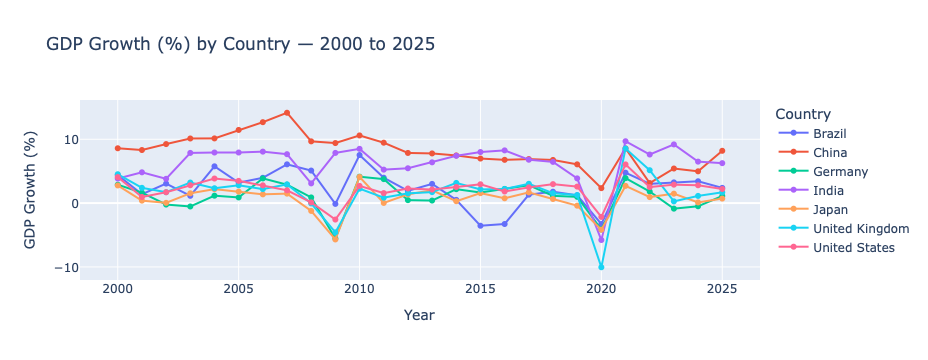

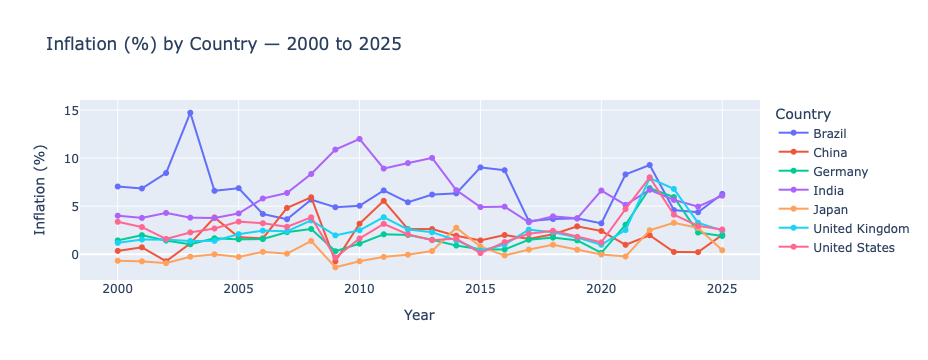

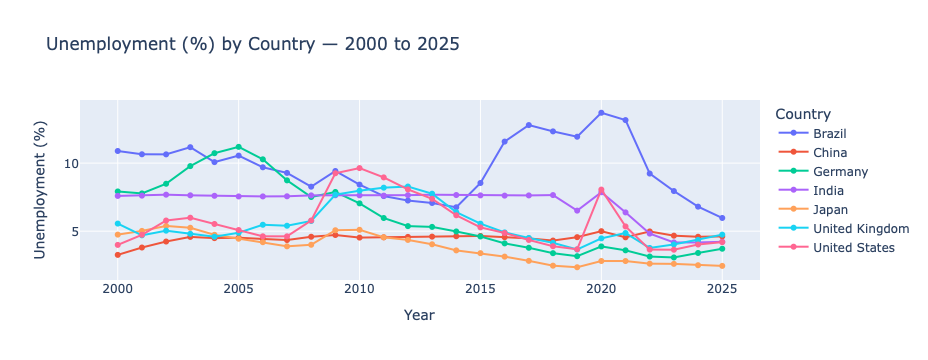

In [5]:
# Trend Charts
for ind in indicators:
    fig = px.line(
        data_clean, x='year', y=ind, color='economy',
        title=f'{ind} by Country — 2000 to 2025',
        labels={'year': 'Year', 'economy': 'Country'},
        markers=True
    )
    fig.update_layout(hovermode='x unified')
    fig.show()

## 6. Cross-country Comparison — Bar Charts

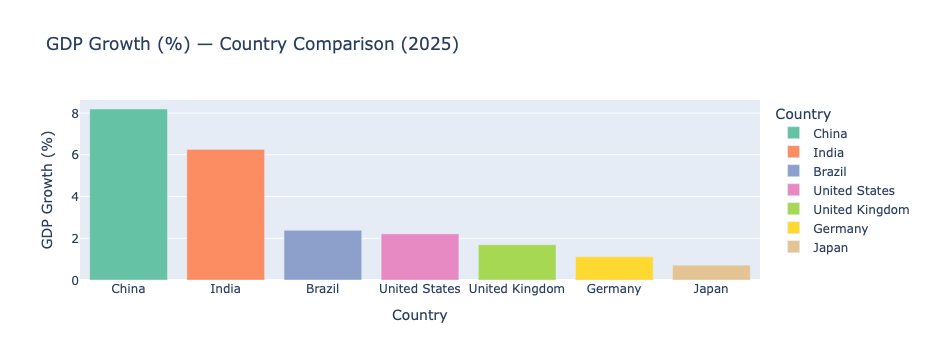

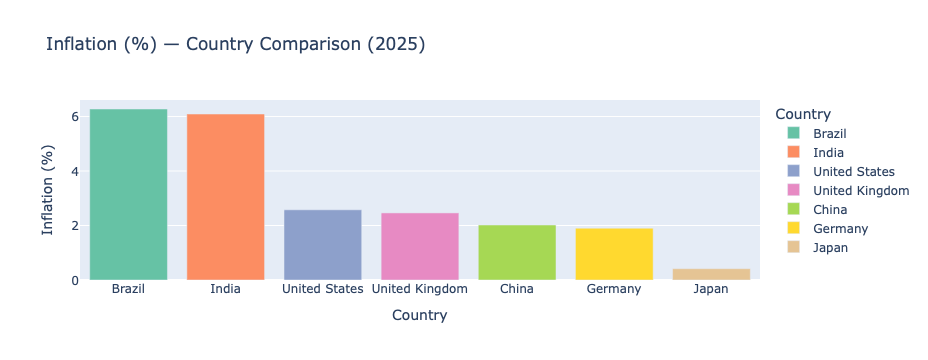

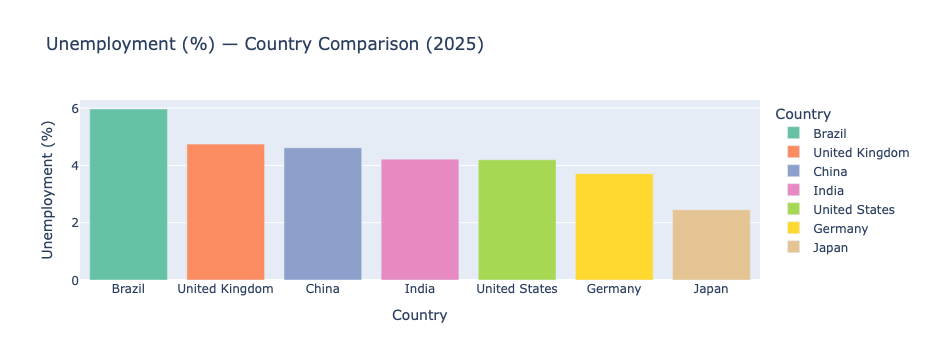

In [6]:
# Cross-country Comparison
# Use 2023 as most complete recent year
latest = data_clean[data_clean['year'] == 2025]

for ind in indicators:
    fig = px.bar(
        latest.sort_values(ind, ascending=False),
        x='economy', y=ind,
        title=f'{ind} — Country Comparison (2025)',
        labels={'economy': 'Country'},
        color='economy',
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig.show()

## 7. Key Insights

In [7]:
# Key Insights
avg = data_clean.groupby('economy')[indicators].mean().round(2)

for ind in indicators:
    top    = avg[ind].idxmax()
    bottom = avg[ind].idxmin()
    print(f'{ind}:')
    print(f'  Highest avg (2000-2025): {top} ({avg.loc[top, ind]}%)')
    print(f'  Lowest  avg (2000-2025): {bottom} ({avg.loc[bottom, ind]}%)')
    print()

GDP Growth (%):
  Highest avg (2000-2025): China (8.19%)
  Lowest  avg (2000-2025): Japan (0.71%)

Inflation (%):
  Highest avg (2000-2025): Brazil (6.28%)
  Lowest  avg (2000-2025): Japan (0.41%)

Unemployment (%):
  Highest avg (2000-2025): Brazil (9.68%)
  Lowest  avg (2000-2025): Japan (3.78%)



## 8. Deeper Analysis and Interpretation

=== Correlation: GDP Growth vs Unemployment ===
       Country  Correlation (GDP vs Unemployment)
 United States                             -0.477
         China                             -0.343
        Brazil                             -0.254
         India                             -0.212
United Kingdom                             -0.115
       Germany                              0.044
         Japan                              0.060

Negative values confirm Okun's Law: higher growth → lower unemployment


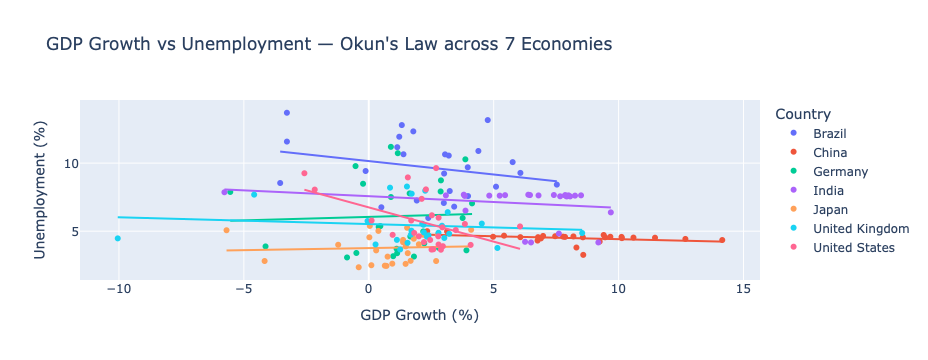

In [8]:
# Correlation Analysis: GDP Growth vs Unemployment
import plotly.express as px

correlations = []
for country in data_clean['economy'].unique():
    subset = data_clean[data_clean['economy'] == country]
    corr = subset['GDP Growth (%)'].corr(subset['Unemployment (%)'])
    correlations.append({
        'Country': country,
        'Correlation (GDP vs Unemployment)': round(corr, 3)
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation (GDP vs Unemployment)')
print("=== Correlation: GDP Growth vs Unemployment ===")
print(corr_df.to_string(index=False))
print("\nNegative values confirm Okun's Law: higher growth → lower unemployment")

fig = px.scatter(
    data_clean, x='GDP Growth (%)', y='Unemployment (%)',
    color='economy', trendline='ols',
    title="GDP Growth vs Unemployment — Okun's Law across 7 Economies",
    labels={'economy': 'Country'}
)
fig.show()

=== COVID-19 Impact: Change from 2019 to 2020 ===
                GDP Drop (pp)  Inflation Change (pp)  Unemployment Rise (pp)
economy                                                                     
United Kingdom         -11.30                  -0.75                    0.82
India                   -9.65                   2.89                    1.35
Germany                 -5.11                  -1.30                    0.72
United States           -4.75                  -0.58                    4.39
Brazil                  -4.50                  -0.52                    1.76
Japan                   -3.77                  -0.49                    0.46
China                   -3.73                  -0.48                    0.44


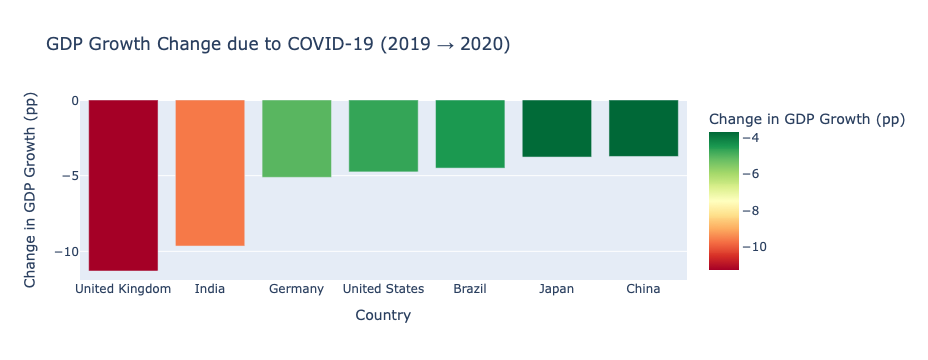

In [9]:
# COVID-19 Shock Analysis (2019 vs 2020)
pre  = data_clean[data_clean['year'] == 2019].set_index('economy')
post = data_clean[data_clean['year'] == 2020].set_index('economy')

shock = pd.DataFrame({
    'GDP Drop (pp)':          (post['GDP Growth (%)'] - pre['GDP Growth (%)']).round(2),
    'Inflation Change (pp)':  (post['Inflation (%)']  - pre['Inflation (%)']).round(2),
    'Unemployment Rise (pp)': (post['Unemployment (%)'] - pre['Unemployment (%)']).round(2)
}).sort_values('GDP Drop (pp)')

print("=== COVID-19 Impact: Change from 2019 to 2020 ===")
print(shock)

fig = px.bar(
    shock.reset_index(), x='economy', y='GDP Drop (pp)',
    title='GDP Growth Change due to COVID-19 (2019 → 2020)',
    labels={'economy': 'Country', 'GDP Drop (pp)': 'Change in GDP Growth (pp)'},
    color='GDP Drop (pp)',
    color_continuous_scale='RdYlGn'
)
fig.show()

## Summary

The analysis reveals five key patterns across the seven economies from 2000 to 2025:

**1. China's sustained growth dominance**
China recorded the highest average GDP growth (8.19%), consistently outperforming all other economies. This reflects rapid industrialisation and capital accumulation consistent with convergence theory.

**2. Okun's Law holds across most economies**
The scatter analysis confirms a negative correlation between GDP growth and unemployment in most countries. Germany's unemployment fell from 11% in 2005 to 3% in 2019 as growth recovered, a textbook example of Okun's Law.

**3. Brazil's structural challenge**
Brazil had the highest average inflation (6.28%) and unemployment (9.68%), yet growth remained modest. This suggests supply-side constraints rather than demand-driven expansion — high inflation without high growth.

**4. COVID-19 asymmetric impact**
The UK suffered the sharpest GDP contraction in 2020 (-10pp), reflecting its service-heavy economy. China was the only economy to maintain positive growth, partly due to early pandemic control measures.

**5. Japan as a persistent outlier**
Japan maintained the lowest inflation (0.41%) and lowest GDP growth (0.71%) throughout the period, reflecting entrenched deflationary expectations that even post-pandemic global inflation failed to significantly disrupt.